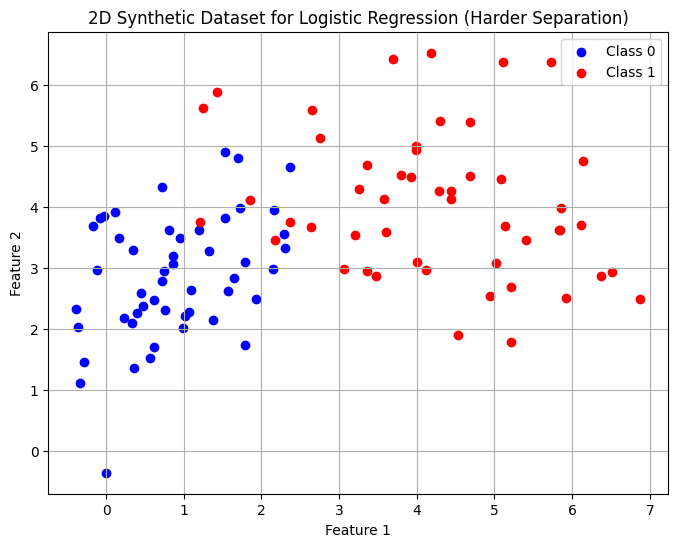

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Generate a 2D dataset
np.random.seed(42)
num_samples = 100

# Class 0 - making the means closer and increasing covariance for harder separation
# Correcting covariance to be symmetric positive-semidefinite
X0 = np.random.multivariate_normal([1, 3], [[0.7, 0.5], [0.5, 1.5]], num_samples // 2)
y0 = np.zeros(num_samples // 2)

# Class 1
# Correcting covariance to be symmetric positive-semidefinite
X1 = np.random.multivariate_normal([4, 4], [[2.5, -0.7], [-0.7, 1.5]], num_samples // 2)
y1 = np.ones(num_samples // 2)

X = np.vstack((X0, X1))
y = np.hstack((y0, y1))

# Plot the dataset
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='blue', label='Class 0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='red', label='Class 1')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('2D Synthetic Dataset for Logistic Regression (Harder Separation)')
plt.legend()
plt.grid(True)
plt.show()

In [2]:
# Add a bias term to X
X_biased = np.hstack((np.ones((X.shape[0], 1)), X))

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def hypothesis(X, w):
    return sigmoid(X @ w)

def compute_gradient(X, y, p):
    return X.T @ (p - y)

def compute_hessian(X, p):
    return X.T @ np.diag(p * (1 - p)) @ X

def plot_decision_boundary(X, y, w, title='Decision Boundary', ax=None):
    if ax is None:
        plt.figure(figsize=(8, 6))
        ax = plt.gca()

    # Plot the dataset
    ax.scatter(X[y == 0][:, 1], X[y == 0][:, 2], color='blue', label='Class 0')
    ax.scatter(X[y == 1][:, 1], X[y == 1][:, 2], color='red', label='Class 1')

    # Plot the decision boundary
    x_min, x_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    y_min, y_max = X[:, 2].min() - 1, X[:, 2].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                             np.linspace(y_min, y_max, 100))

    # Calculate the decision boundary function value for each point in the meshgrid
    # The decision boundary is where w[0] + w[1]*x1 + w[2]*x2 = 0
    Z = w[0] + w[1] * xx + w[2] * yy
    ax.contour(xx, yy, Z, levels=[0], colors='green', linestyles='--')

    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_title(title)
    ax.legend()
    ax.grid(True)


print("Logistic regression functions and plot_decision_boundary function defined.")

Logistic regression functions and plot_decision_boundary function defined.


Starting Newton-Raphson training and plotting decision boundaries per iteration...


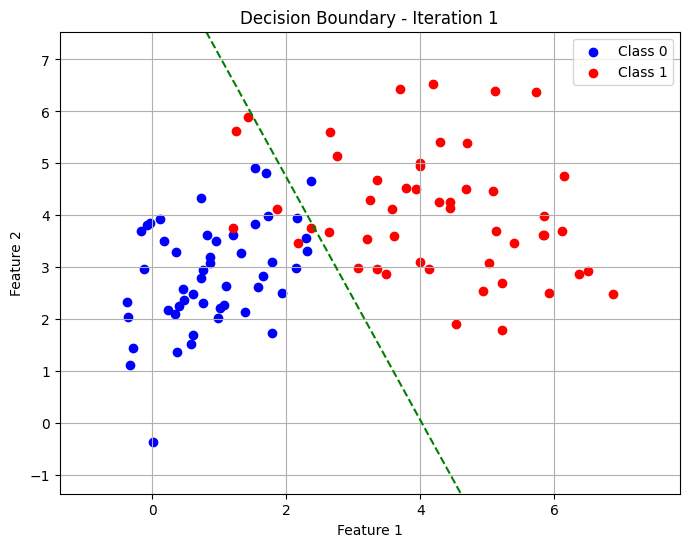

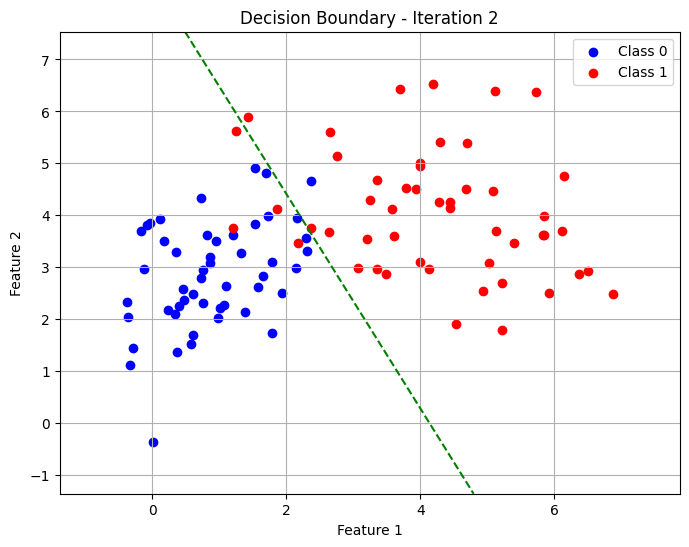

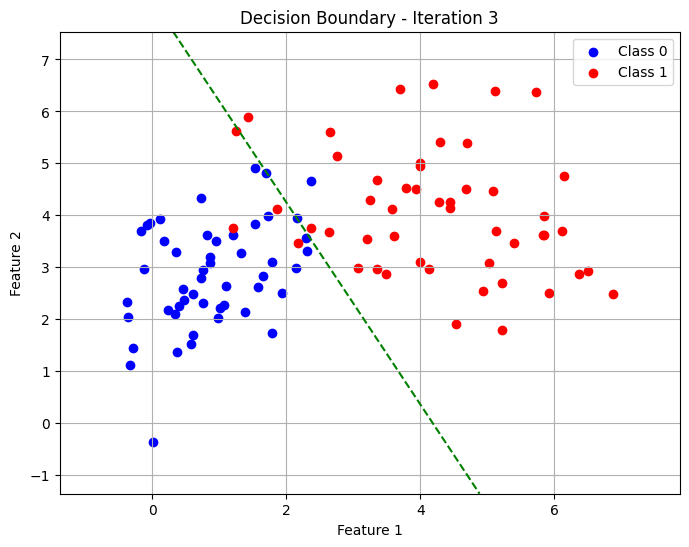

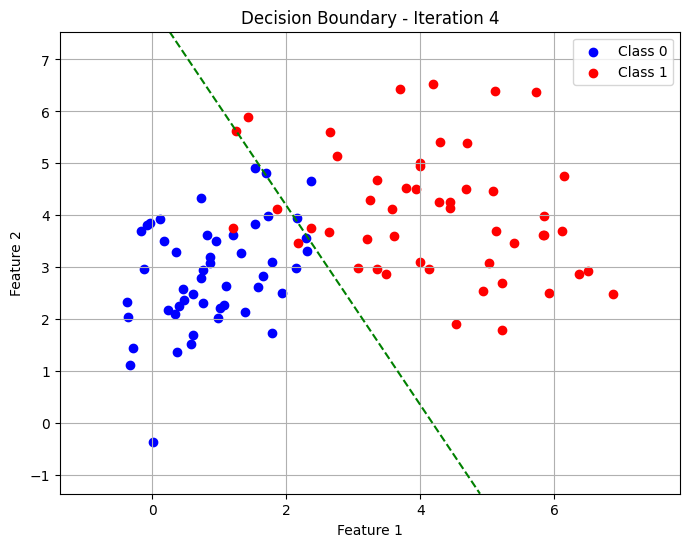

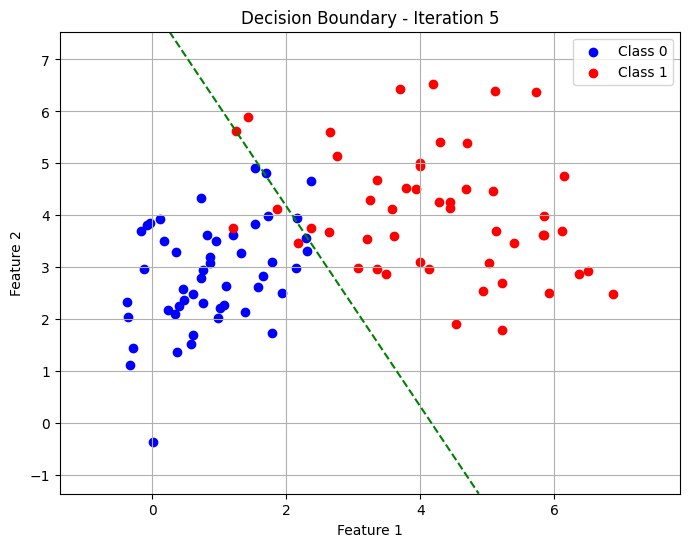

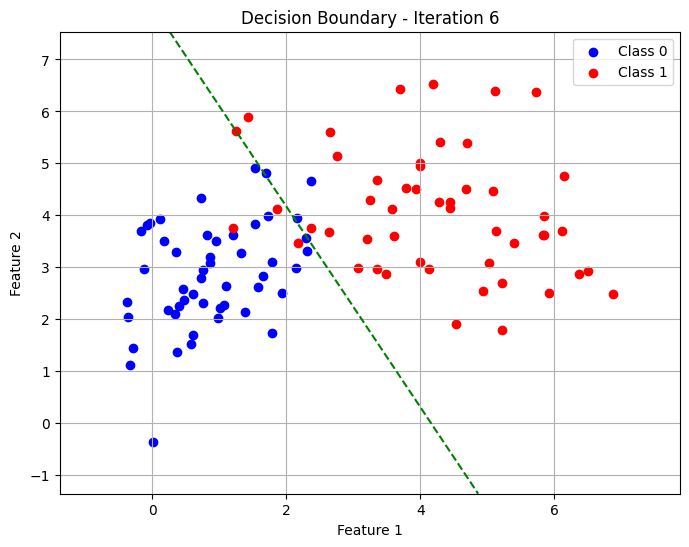

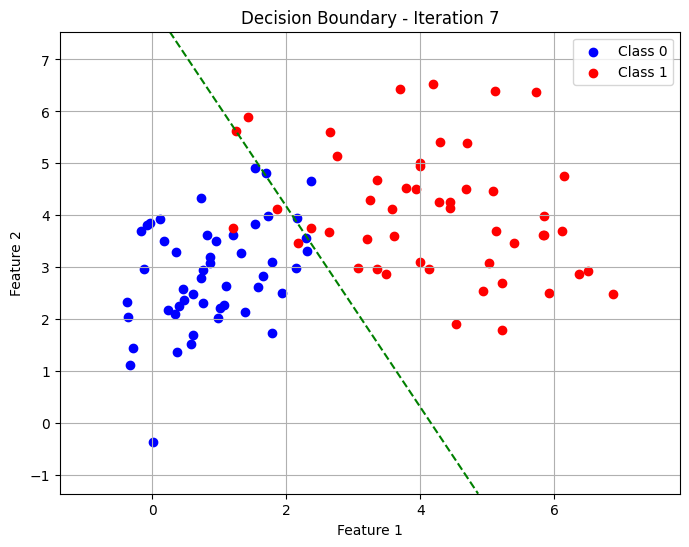

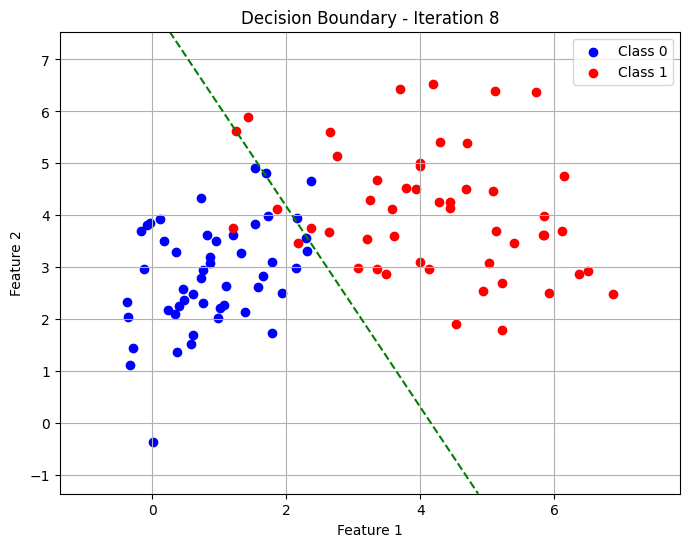

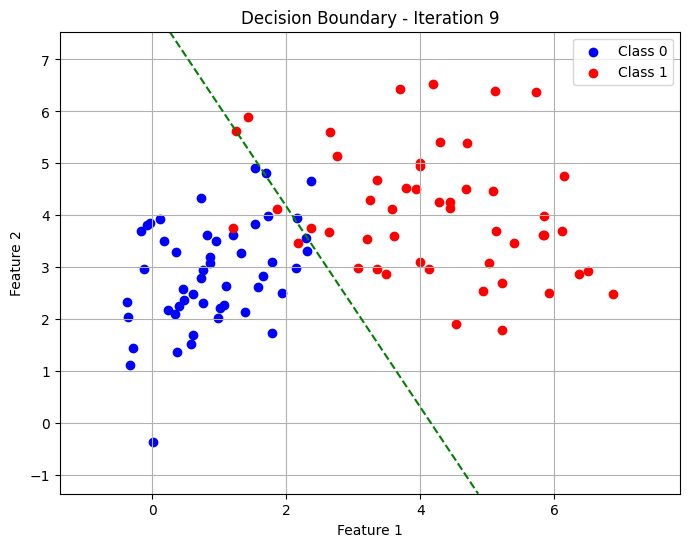

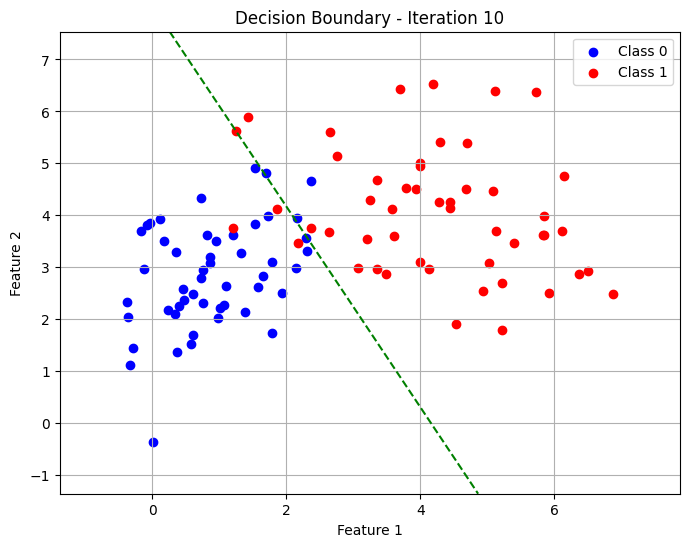

Final weights after 10 iterations: [-11.94157755   2.87063941   1.48664068]


In [3]:
import numpy.linalg as LA

# Initialize weights with zeros (including bias term)
w = np.zeros(X_biased.shape[1])

num_iterations = 10

print('Starting Newton-Raphson training and plotting decision boundaries per iteration...')

for i in range(num_iterations):
    p = hypothesis(X_biased, w)
    grad = compute_gradient(X_biased, y, p)
    H = compute_hessian(X_biased, p)

    # Update weights using Newton-Raphson step
    try:
        w = w - LA.inv(H) @ grad
    except LA.LinAlgError:
        print(f"Singular matrix encountered at iteration {i}. Stopping training.")
        break

    # Plot decision boundary for current iteration
    plt.figure(figsize=(8, 6))
    ax = plt.gca()
    plot_decision_boundary(X_biased, y, w, title=f'Decision Boundary - Iteration {i+1}', ax=ax)
    plt.show() # Display each plot immediately after generation

print(f"Final weights after {num_iterations} iterations: {w}")